# GreenTech Solutions Ltd - Flower Classification Project

## Link utili per Google drive:
https://drive.google.com/drive/folders/12ICyXP7Oa2Tept7M4XWBhIdEp1MMCYl9?usp=drive_link

## Dataset
- **Daisy** (Margherita)
- **Dandelion** (Tarassaco)

## Tecnologie
- PyTorch + TIMM (Transfer Learning)
- Albumentations (Data Augmentation)

## Configurazione Training
- **Transfer Learning**: Modelli pre-trained su ImageNet
- **Data Augmentation**: HorizontalFlip, VerticalFlip, Rotate, RandomBrightnessContrast, ColorJitter, GaussianBlur
- **Optimizer**: AdamW con weight decay (0.01)
- **Scheduler**: CosineAnnealingLR
- **Early Stopping**: patience=10, min_delta=0.001


In [25]:
#  Setup Ambiente e Verifica GPU
import torch
print(f"PyTorch {torch.__version__}, CUDA {torch.cuda.is_available()}")
!pip install timm ultralytics supervision albumentations -q

PyTorch 2.9.0+cu126, CUDA True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import glob
from collections import Counter
import json
from datetime import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Seed per riproducibilità
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Mounted at /content/drive
Device: cuda


In [3]:
# Setup Directories e Download Dataset
PROJECT_DIR = '/content/drive/MyDrive/CV_project'
DATASET_DIR = f'{PROJECT_DIR}/dataset'
MODELS_DIR = f'{PROJECT_DIR}/models'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Download solo se non esiste già
if not os.path.exists(f'{DATASET_DIR}/train') or not os.path.exists(f'{DATASET_DIR}/test'):
    print("Download dataset...")
    url = 'https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz'
    tar = f'{PROJECT_DIR}/dataset.tar.gz'
    !curl -L -o "{tar}" {url}
    !tar -xzf "{tar}" -C "{DATASET_DIR}"
    os.remove(tar)
    print("Dataset estratto")
else:
    print("Dataset già presente")

Dataset già presente


---
## 📊 FASE 1: Exploratory Data Analysis (EDA)

📊 Distribuzione Dataset:
           train  valid  test
daisy       1058    326   154
dandelion   1492    402   210

📈 Totale immagini: 3642


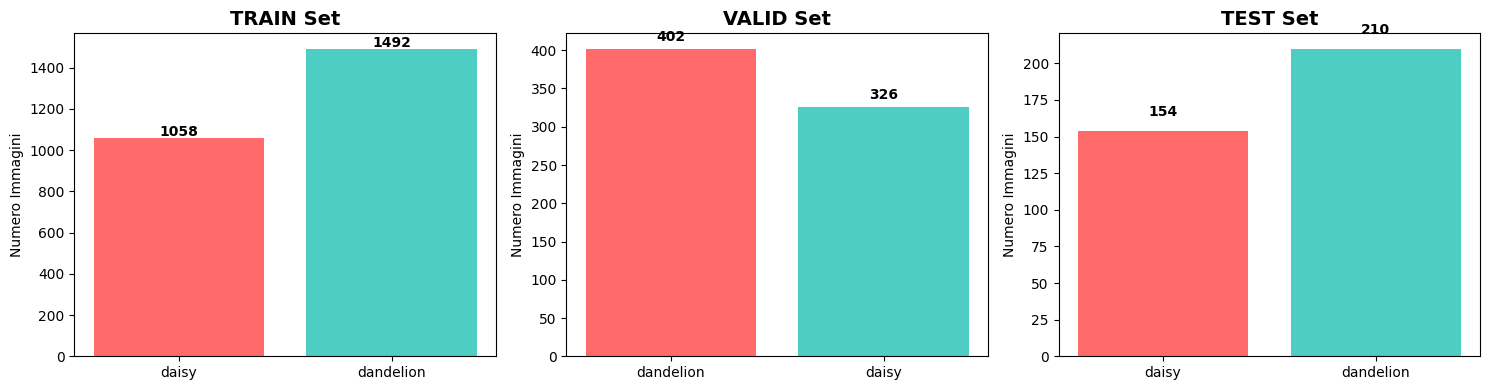


Bilanciamento Classi (Train):
  daisy: 1058 (41.5%)
  dandelion: 1492 (58.5%)


In [4]:
# Analisi struttura dataset
def analyze_dataset(base_dir):
    """Analizza la struttura del dataset"""
    stats = {}

    for split in ['train', 'valid', 'test']:
        split_path = os.path.join(base_dir, split)
        if not os.path.exists(split_path):
            continue

        stats[split] = {}
        classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            stats[split][cls] = len(images)

    return stats

# Analisi dataset
dataset_stats = analyze_dataset(DATASET_DIR)

# Crea DataFrame per visualizzazione
df_stats = pd.DataFrame(dataset_stats).fillna(0).astype(int)
print("📊 Distribuzione Dataset:")
print(df_stats)
print(f"\n📈 Totale immagini: {df_stats.sum().sum()}")

# Visualizza distribuzione
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, split in enumerate(['train', 'valid', 'test']):
    if split in dataset_stats:
        data = dataset_stats[split]
        axes[idx].bar(data.keys(), data.values(), color=['#FF6B6B', '#4ECDC4'])
        axes[idx].set_title(f'{split.upper()} Set', fontsize=14, fontweight='bold')
        axes[idx].set_ylabel('Numero Immagini')
        for i, (k, v) in enumerate(data.items()):
            axes[idx].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Verifica bilanciamento
print("\nBilanciamento Classi (Train):")
if 'train' in dataset_stats:
    train_total = sum(dataset_stats['train'].values())
    for cls, count in dataset_stats['train'].items():
        percentage = (count / train_total) * 100
        print(f"  {cls}: {count} ({percentage:.1f}%)")

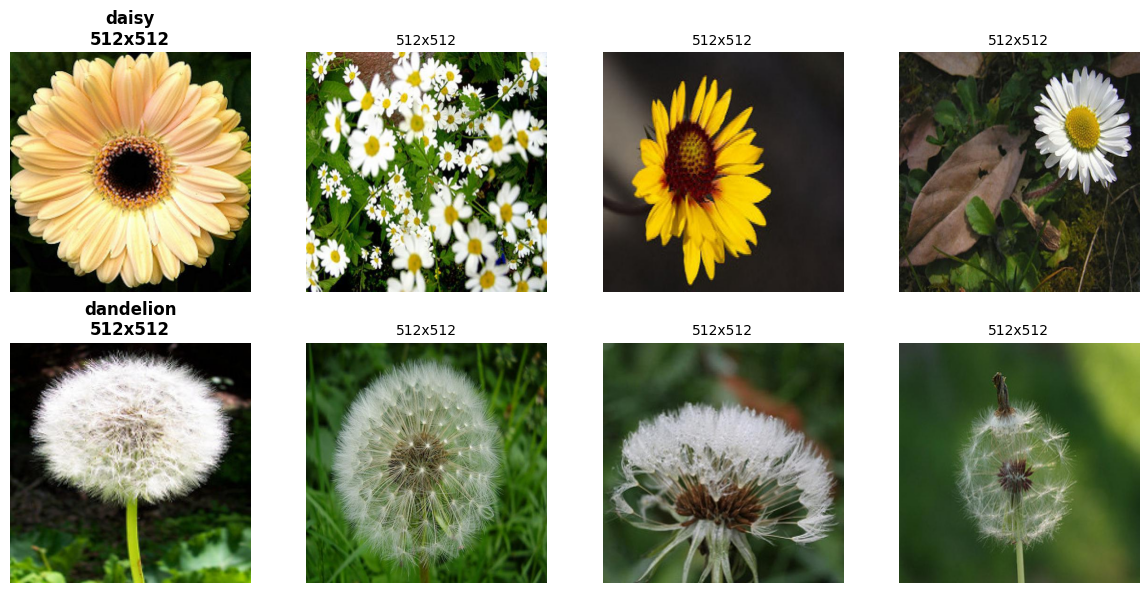

In [5]:
# Visualizza esempi di immagini
def show_samples(base_dir, split='train', samples_per_class=3):
    """Visualizza esempi di immagini per ogni classe"""
    split_path = os.path.join(base_dir, split)
    classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])

    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(12, 6))

    for i, cls in enumerate(classes):
        cls_path = os.path.join(split_path, cls)
        # Modifica: Escludi file che iniziano con '._'
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._')]
        samples = np.random.choice(images, min(samples_per_class, len(images)), replace=False)

        for j, img_name in enumerate(samples):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f'{cls}\n{img.size[0]}x{img.size[1]}',
                                     fontweight='bold', fontsize=12)
            else:
                axes[i, j].set_title(f'{img.size[0]}x{img.size[1]}', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/dataset_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples(DATASET_DIR, split='train', samples_per_class=4)

Analyzing daisy:   0%|          | 0/200 [00:00<?, ?it/s]

Analyzing dandelion:   0%|          | 0/200 [00:00<?, ?it/s]

📐 Analisi Dimensioni (400 immagini campionate):
  Width:  min=512, max=512, mean=512
  Height: min=512, max=512, mean=512


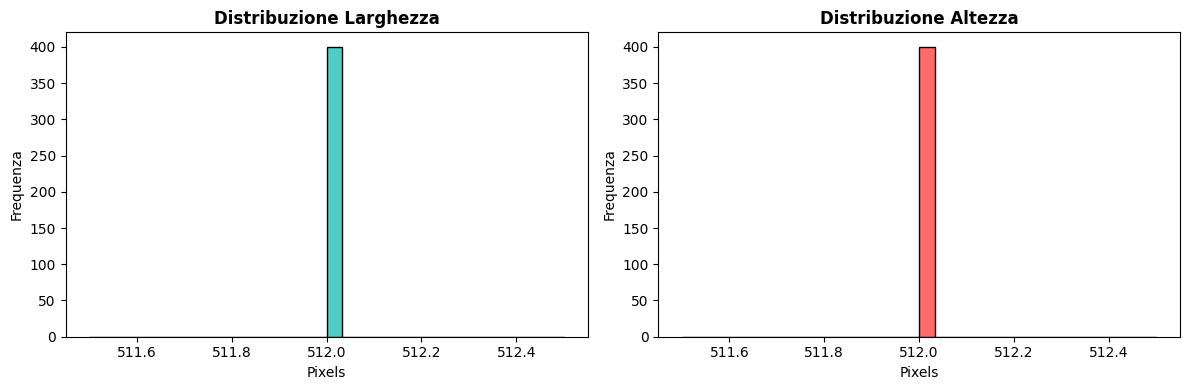

In [6]:
# Analisi dimensioni immagini
def analyze_image_sizes(base_dir, split='train', sample_size=200):
    """Analizza le dimensioni delle immagini"""
    sizes = []
    split_path = os.path.join(base_dir, split)
    classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        # Modifica: Escludi file che iniziano con '._'
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._')]

        # Handle cases where there might be no valid images after filtering
        if not images:
            continue

        samples = np.random.choice(images, min(sample_size, len(images)), replace=False)

        for img_name in tqdm(samples, desc=f'Analyzing {cls}', leave=False):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            sizes.append(img.size)

    if not sizes:
        print("Nessuna immagine valida trovata per l'analisi delle dimensioni.")
        return

    widths = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]

    print(f"📐 Analisi Dimensioni ({len(sizes)} immagini campionate):")
    print(f"  Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}")
    print(f"  Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}")

    # Visualizza distribuzione
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths, bins=30, color='#4ECDC4', edgecolor='black')
    axes[0].set_title('Distribuzione Larghezza', fontweight='bold')
    axes[0].set_xlabel('Pixels')
    axes[0].set_ylabel('Frequenza')

    axes[1].hist(heights, bins=30, color='#FF6B6B', edgecolor='black')
    axes[1].set_title('Distribuzione Altezza', fontweight='bold')
    axes[1].set_xlabel('Pixels')
    axes[1].set_ylabel('Frequenza')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/image_sizes_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

analyze_image_sizes(DATASET_DIR, split='train')

---
## 🔧 FASE 2: Dataset Custom e Data Augmentation

In [7]:
# Custom Dataset con Albumentations
class FlowerDataset(Dataset):
    """Custom Dataset per Flower Classification"""

    def __init__(self, data_dir, split='train', transform=None):
        self.data_dir = os.path.join(data_dir, split)
        self.transform = transform
        self.images = []
        self.labels = []

        # Mappa classi
        self.classes = sorted([d for d in os.listdir(self.data_dir)
                              if os.path.isdir(os.path.join(self.data_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        # Carica immagini
        for cls in self.classes:
            cls_path = os.path.join(self.data_dir, cls)
            for img_name in os.listdir(cls_path):
                # Modifica: Escludi file che iniziano con '._'
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')) and not img_name.startswith('._'):
                    self.images.append(os.path.join(cls_path, img_name))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = np.array(Image.open(img_path).convert('RGB'))
        label = self.labels[idx]

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

print("FlowerDataset creato!")

FlowerDataset creato!


In [8]:
# Definizione Trasformazioni e Augmentation
IMG_SIZE = 224  # Standard per ImageNet pre-trained models
BATCH_SIZE = 32

# ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms con augmentation
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ColorJitter(p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# Validation/Test transforms (no augmentation)
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")

   Image size: 224x224
   Batch size: 32


In [9]:
# Creazione DataLoaders
train_dataset = FlowerDataset(DATASET_DIR, split='train', transform=train_transform)
val_dataset = FlowerDataset(DATASET_DIR, split='valid', transform=val_transform)
test_dataset = FlowerDataset(DATASET_DIR, split='test', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print("DataLoaders creati!")
print(f"   Train: {len(train_dataset)} immagini, {len(train_loader)} batches")
print(f"   Val:   {len(val_dataset)} immagini, {len(val_loader)} batches")
print(f"   Test:  {len(test_dataset)} immagini, {len(test_loader)} batches")
print(f"\n   Classi: {train_dataset.classes}")

DataLoaders creati!
   Train: 1275 immagini, 40 batches
   Val:   364 immagini, 12 batches
   Test:  182 immagini, 6 batches

   Classi: ['daisy', 'dandelion']


Esempi di Data Augmentation:


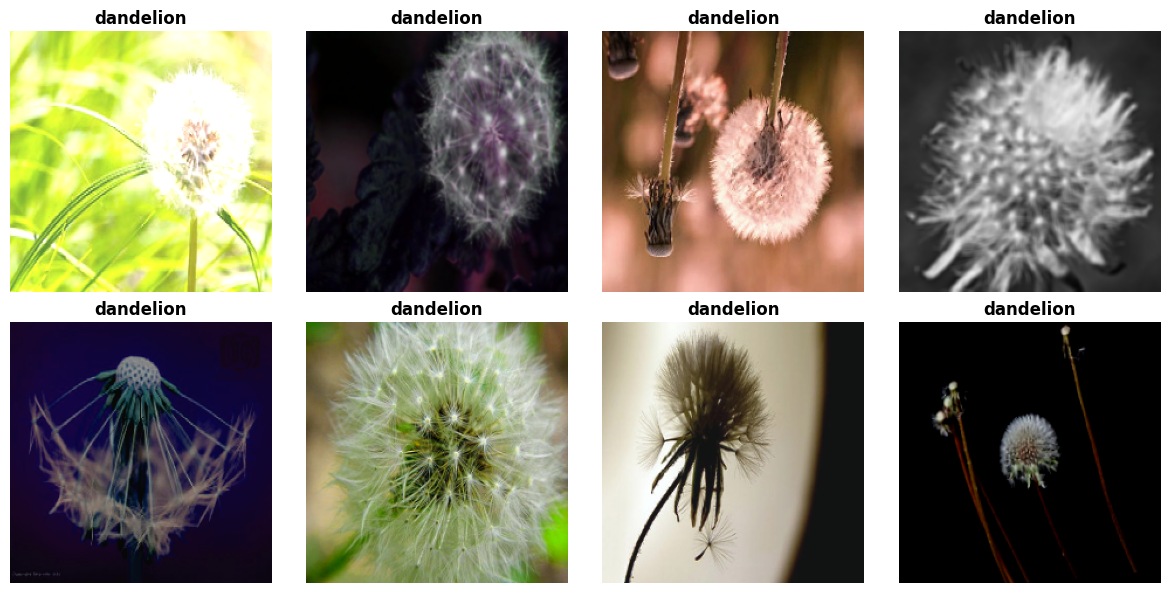

In [10]:
# Visualizza batch con augmentation
def show_augmented_batch(loader, num_images=8):
    """Visualizza un batch di immagini augmentate"""
    images, labels = next(iter(loader))

    # Denormalize per visualizzazione
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(min(num_images, len(images))):
        img = images[i].permute(1, 2, 0).numpy()
        label = train_dataset.classes[labels[i]]
        axes[i].imshow(img)
        axes[i].set_title(f'{label}', fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/augmented_batch.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Esempi di Data Augmentation:")
show_augmented_batch(train_loader)

---
## 🧠 FASE 3: Definizione Modelli con Transfer Learning

In [11]:
# Funzione per creare modelli TIMM
def create_model(model_name, num_classes=2, pretrained=True):
    """Crea un modello usando TIMM con Transfer Learning"""
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    return model

# Lista modelli da testare (ordinati per velocità/efficienza)
MODELS_TO_TEST = [
    'efficientnet_b0',      # Veloce ed efficiente
    'resnet50',              # Robusto e affidabile
    'convnext_tiny',         # State-of-the-art CNN
]

print("Modelli disponibili per il training:")
for i, model_name in enumerate(MODELS_TO_TEST, 1):
    print(f"   {i}. {model_name}")

Modelli disponibili per il training:
   1. efficientnet_b0
   2. resnet50
   3. convnext_tiny


---
## 🏋️ FASE 4: Training con Checkpoint e Early Stopping

In [12]:
# Funzioni di supporto per training
class EarlyStopping:
    """Early Stopping per evitare overfitting"""

    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_score):
        if self.best_score is None:
            self.best_score = val_score
        elif val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_score
            self.counter = 0

        return self.early_stop


def save_checkpoint(model, optimizer, scheduler, epoch, train_loss, val_loss, val_f1,
                   model_name, checkpoint_dir, is_best=False):
    """Salva un checkpoint del modello"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_f1': val_f1,
        'model_name': model_name
    }

    os.makedirs(checkpoint_dir, exist_ok=True)

    if is_best:
        path = os.path.join(checkpoint_dir, 'best_model.pt')
        torch.save(checkpoint, path)
        print(f"💾 Best model salvato! (F1: {val_f1:.4f})")
    else:
        path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch}.pt')
        torch.save(checkpoint, path)
        print(f"💾 Checkpoint salvato: epoch {epoch}")


def load_checkpoint(checkpoint_path, model, optimizer=None, scheduler=None):
    """Carica un checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if scheduler and checkpoint.get('scheduler_state_dict'):
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    return checkpoint


def find_latest_checkpoint(checkpoint_dir):
    """Trova l'ultimo checkpoint disponibile"""
    checkpoints = glob.glob(os.path.join(checkpoint_dir, 'checkpoint_epoch_*.pt'))
    if not checkpoints:
        return None

    # Ordina per numero di epoca
    checkpoints.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))
    return checkpoints[-1]


print("Funzioni di supporto per training definite!")

Funzioni di supporto per training definite!


In [13]:
# Training Loop Principale
def train_epoch(model, loader, criterion, optimizer, device):
    """Training per una singola epoca"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_f1


def validate_epoch(model, loader, criterion, device):
    """Validazione per una singola epoca"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss, epoch_f1


print("Training loop definito!")

Training loop definito!


In [14]:
# Funzione di Training Completa con Resume
def train_model(model_name, num_epochs=30, learning_rate=1e-4, checkpoint_freq=5):
    """
    Training completo con:
    - Resume automatico da checkpoint
    - Early stopping
    - Salvataggio periodico
    - Best model tracking
    """
    print(f"\n{'='*60}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*60}")

    # Setup directories
    model_dir = os.path.join(MODELS_DIR, model_name)
    os.makedirs(model_dir, exist_ok=True)

    # Controlla se esiste già il best model
    best_model_path = os.path.join(model_dir, 'best_model.pt')
    if os.path.exists(best_model_path):
        print(f"Best model già esistente!")
        checkpoint = torch.load(best_model_path, map_location=device)
        print(f"   Epoch: {checkpoint['epoch']}, Val F1: {checkpoint['val_f1']:.4f}")
        response = input("   Vuoi rifare il training? (y/n): ")
        if response.lower() != 'y':
            print("   Training saltato, uso il modello esistente.")
            return checkpoint

    # Crea modello
    print("\nCreazione modello...")
    model = create_model(model_name, num_classes=len(train_dataset.classes))
    model = model.to(device)

    # Ottimizzatore e loss
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Early stopping
    early_stopping = EarlyStopping(patience=10, min_delta=0.001)

    # Controlla checkpoint esistenti per resume
    start_epoch = 0
    best_val_f1 = 0.0
    history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}

    latest_checkpoint = find_latest_checkpoint(model_dir)
    if latest_checkpoint:
        print(f"\nCheckpoint trovato: {os.path.basename(latest_checkpoint)}")
        checkpoint = load_checkpoint(latest_checkpoint, model, optimizer, scheduler)
        start_epoch = checkpoint['epoch']
        best_val_f1 = checkpoint.get('val_f1', 0.0)
        print(f"   Riprendo da epoch {start_epoch + 1}")

    # Training loop
    print(f"\nInizio training da epoch {start_epoch + 1} a {num_epochs}...\n")

    for epoch in range(start_epoch, num_epochs):
        epoch_start = datetime.now()

        # Training
        train_loss, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validation
        val_loss, val_f1 = validate_epoch(model, val_loader, criterion, device)

        # Scheduler step
        scheduler.step()

        # Salva storia
        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        # Tempo epoca
        epoch_time = (datetime.now() - epoch_start).total_seconds()

        # Print progress
        print(f"Epoch [{epoch+1}/{num_epochs}] ({epoch_time:.1f}s) - "
              f"Train Loss: {train_loss:.4f}, Train F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")

        # Salva best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            save_checkpoint(model, optimizer, scheduler, epoch + 1,
                          train_loss, val_loss, val_f1, model_name, model_dir, is_best=True)

        # Salva checkpoint periodico
        if (epoch + 1) % checkpoint_freq == 0:
            save_checkpoint(model, optimizer, scheduler, epoch + 1,
                          train_loss, val_loss, val_f1, model_name, model_dir, is_best=False)

        # Early stopping check
        if early_stopping(val_f1):
            print(f"\n Early stopping attivato: (patience={early_stopping.patience})")
            break

    # Salva history
    history_path = os.path.join(model_dir, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    print(f"\nTraining completato!")
    print(f"   Best Val F1: {best_val_f1:.4f}")

    # Carica best model per return
    best_checkpoint = torch.load(best_model_path, map_location=device)
    return best_checkpoint


print("Funzione di training completa definita!")

Funzione di training completa definita!


In [15]:
# TRAINING DEI MODELLI
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
CHECKPOINT_FREQ = 5

print("\n" + "="*60)
print("🎯 CONFIGURAZIONE TRAINING")
print("="*60)
print(f"Max Epochs: {NUM_EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Checkpoint Frequency: ogni {CHECKPOINT_FREQ} epoche")
print(f"Early Stopping: patience=10")
print(f"Device: {device}")
print("\n⏱️  Tempo stimato per modello: ~30-60 minuti su GPU T4")

# Dictionary per salvare i risultati
results = {}

# Training di tutti i modelli
for model_name in MODELS_TO_TEST:
    checkpoint = train_model(
        model_name=model_name,
        num_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,
        checkpoint_freq=CHECKPOINT_FREQ
    )

    results[model_name] = {
        'val_f1': checkpoint['val_f1'],
        'val_loss': checkpoint['val_loss'],
        'epoch': checkpoint['epoch']
    }

    print(f"\n{'='*60}\n")

# Riepilogo risultati
print("\n" + "="*60)
print("RIEPILOGO RISULTATI TRAINING")
print("="*60)
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values('val_f1', ascending=False)
print(df_results)

best_model_name = df_results.index[0]
print(f"\nMIGLIOR MODELLO: {best_model_name}")
print(f"   Val F1: {df_results.loc[best_model_name, 'val_f1']:.4f}")


🎯 CONFIGURAZIONE TRAINING
Max Epochs: 30
Learning Rate: 0.0001
Checkpoint Frequency: ogni 5 epoche
Early Stopping: patience=10
Device: cuda

⏱️  Tempo stimato per modello: ~30-60 minuti su GPU T4

TRAINING: efficientnet_b0
Best model già esistente!
   Epoch: 16, Val F1: 0.9528
   Vuoi rifare il training? (y/n): n
   Training saltato, uso il modello esistente.



TRAINING: resnet50
Best model già esistente!
   Epoch: 14, Val F1: 0.9722
   Vuoi rifare il training? (y/n): n
   Training saltato, uso il modello esistente.



TRAINING: convnext_tiny
Best model già esistente!
   Epoch: 15, Val F1: 0.9917
   Vuoi rifare il training? (y/n): n
   Training saltato, uso il modello esistente.



RIEPILOGO RISULTATI TRAINING
                   val_f1  val_loss  epoch
convnext_tiny    0.991663  0.063482   15.0
resnet50         0.972225  0.080670   14.0
efficientnet_b0  0.952809  0.189374   16.0

MIGLIOR MODELLO: convnext_tiny
   Val F1: 0.9917



Training Curves di Tutti i Modelli:


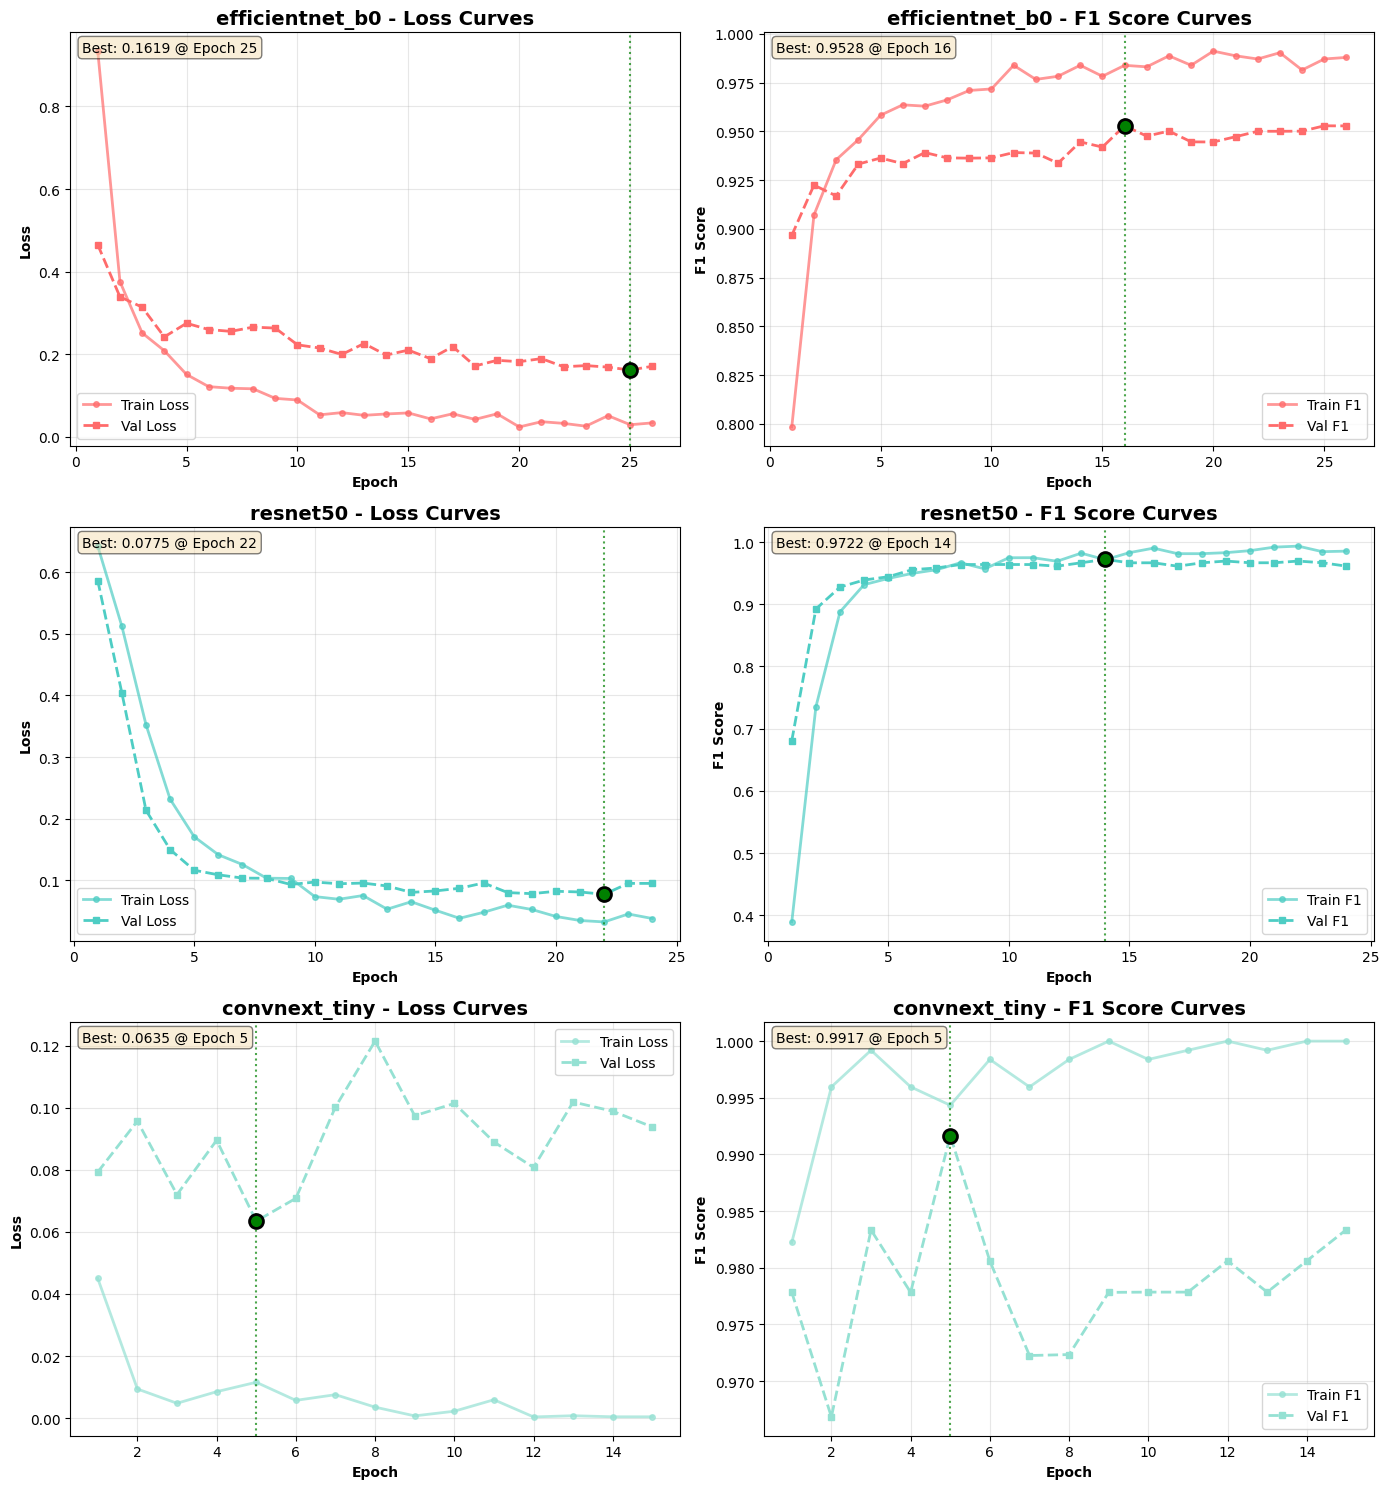

In [16]:
# Visualizza training history di tutti i modelli
def plot_all_training_histories():
    """Visualizza le curve di training di tutti i modelli"""
    fig, axes = plt.subplots(len(MODELS_TO_TEST), 2, figsize=(14, 5 * len(MODELS_TO_TEST)))

    if len(MODELS_TO_TEST) == 1:
        axes = axes.reshape(1, -1)

    colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']

    for idx, model_name in enumerate(MODELS_TO_TEST):
        history_path = os.path.join(MODELS_DIR, model_name, 'training_history.json')

        if not os.path.exists(history_path):
            print(f" History non trovata per {model_name}")
            continue

        with open(history_path, 'r') as f:
            history = json.load(f)

        epochs = range(1, len(history['train_loss']) + 1)
        color = colors[idx % len(colors)]

        # Loss plot
        axes[idx, 0].plot(epochs, history['train_loss'], color=color, linestyle='-',
                         linewidth=2, label='Train Loss', marker='o', markersize=4, alpha=0.7)
        axes[idx, 0].plot(epochs, history['val_loss'], color=color, linestyle='--',
                         linewidth=2, label='Val Loss', marker='s', markersize=4)
        axes[idx, 0].set_title(f'{model_name} - Loss Curves', fontsize=14, fontweight='bold')
        axes[idx, 0].set_xlabel('Epoch', fontweight='bold')
        axes[idx, 0].set_ylabel('Loss', fontweight='bold')
        axes[idx, 0].legend(loc='best')
        axes[idx, 0].grid(True, alpha=0.3)

        # Mark best epoch
        best_epoch = np.argmin(history['val_loss']) + 1
        best_loss = min(history['val_loss'])
        axes[idx, 0].axvline(x=best_epoch, color='green', linestyle=':', alpha=0.7)
        axes[idx, 0].scatter([best_epoch], [best_loss], color='green', s=100,
                            zorder=5, edgecolors='black', linewidths=2)

        # F1 Score plot
        axes[idx, 1].plot(epochs, history['train_f1'], color=color, linestyle='-',
                         linewidth=2, label='Train F1', marker='o', markersize=4, alpha=0.7)
        axes[idx, 1].plot(epochs, history['val_f1'], color=color, linestyle='--',
                         linewidth=2, label='Val F1', marker='s', markersize=4)
        axes[idx, 1].set_title(f'{model_name} - F1 Score Curves', fontsize=14, fontweight='bold')
        axes[idx, 1].set_xlabel('Epoch', fontweight='bold')
        axes[idx, 1].set_ylabel('F1 Score', fontweight='bold')
        axes[idx, 1].legend(loc='best')
        axes[idx, 1].grid(True, alpha=0.3)

        # Mark best epoch
        best_epoch_f1 = np.argmax(history['val_f1']) + 1
        best_f1 = max(history['val_f1'])
        axes[idx, 1].axvline(x=best_epoch_f1, color='green', linestyle=':', alpha=0.7)
        axes[idx, 1].scatter([best_epoch_f1], [best_f1], color='green', s=100,
                            zorder=5, edgecolors='black', linewidths=2)

        # Add text with best metrics
        axes[idx, 0].text(0.02, 0.98, f'Best: {best_loss:.4f} @ Epoch {best_epoch}',
                         transform=axes[idx, 0].transAxes, fontsize=10,
                         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        axes[idx, 1].text(0.02, 0.98, f'Best: {best_f1:.4f} @ Epoch {best_epoch_f1}',
                         transform=axes[idx, 1].transAxes, fontsize=10,
                         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/all_models_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nTraining Curves di Tutti i Modelli:")
plot_all_training_histories()

In [17]:
#  Carica il miglior modello per valutazione
print(f"\n{'='*60}")
print(f"VALUTAZIONE MODELLO MIGLIORE: {best_model_name}")
print(f"{'='*60}\n")

# Carica il best model
best_model_path = os.path.join(MODELS_DIR, best_model_name, 'best_model.pt')
best_checkpoint = torch.load(best_model_path, map_location=device)

# Crea e carica il modello
best_model = create_model(best_model_name, num_classes=len(train_dataset.classes))
best_model.load_state_dict(best_checkpoint['model_state_dict'])
best_model = best_model.to(device)
best_model.eval()

print(f"Modello caricato!")
print(f"   Training epoch: {best_checkpoint['epoch']}")
print(f"   Validation F1: {best_checkpoint['val_f1']:.4f}")


VALUTAZIONE MODELLO MIGLIORE: convnext_tiny



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Modello caricato!
   Training epoch: 15
   Validation F1: 0.9917


In [18]:
#  Valutazione su Test Set
def evaluate_model(model, loader, device, dataset_name='Test'):
    """Valutazione completa del modello"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f'Evaluating on {dataset_name}'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Valuta su test set
test_preds, test_labels, test_probs = evaluate_model(best_model, test_loader, device, 'Test Set')

# Calcola metriche
test_f1 = f1_score(test_labels, test_preds, average='macro')
test_accuracy = (test_preds == test_labels).mean()

print(f"\n{'='*60}")
print(f"RISULTATI SU TEST SET")
print(f"{'='*60}")
print(f"\nMetriche Globali:")
print(f"   Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   F1-Score (macro): {test_f1:.4f}")

# Classification report dettagliato
print(f"\nClassification Report:\n")
class_names = train_dataset.classes
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

Evaluating on Test Set:   0%|          | 0/6 [00:00<?, ?it/s]


RISULTATI SU TEST SET

Metriche Globali:
   Accuracy:  0.9725 (97.25%)
   F1-Score (macro): 0.9717

Classification Report:

              precision    recall  f1-score   support

       daisy     0.9865    0.9481    0.9669        77
   dandelion     0.9630    0.9905    0.9765       105

    accuracy                         0.9725       182
   macro avg     0.9747    0.9693    0.9717       182
weighted avg     0.9729    0.9725    0.9724       182




Confusion Matrix:


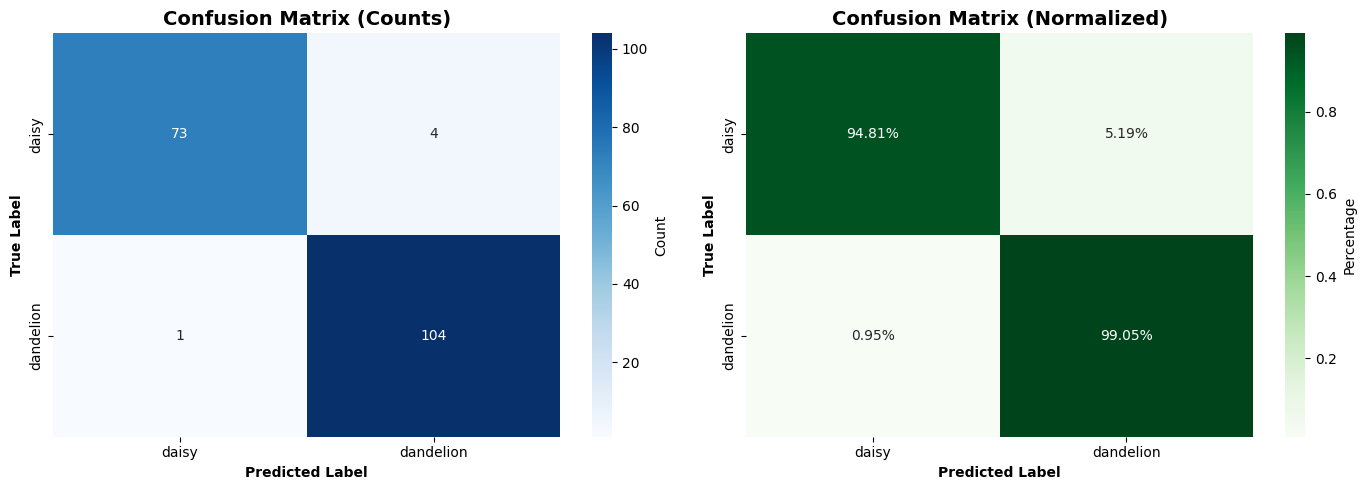

In [19]:
# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, classes, save_path=None):
    """Visualizza confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix (counts)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontweight='bold')
    axes[0].set_xlabel('Predicted Label', fontweight='bold')

    # Confusion Matrix (normalized)
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=classes, yticklabels=classes, ax=axes[1], cbar_kws={'label': 'Percentage'})
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontweight='bold')
    axes[1].set_xlabel('Predicted Label', fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("\nConfusion Matrix:")
plot_confusion_matrix(test_labels, test_preds, class_names,
                     save_path=f'{PROJECT_DIR}/confusion_matrix_{best_model_name}.png')


Training History:


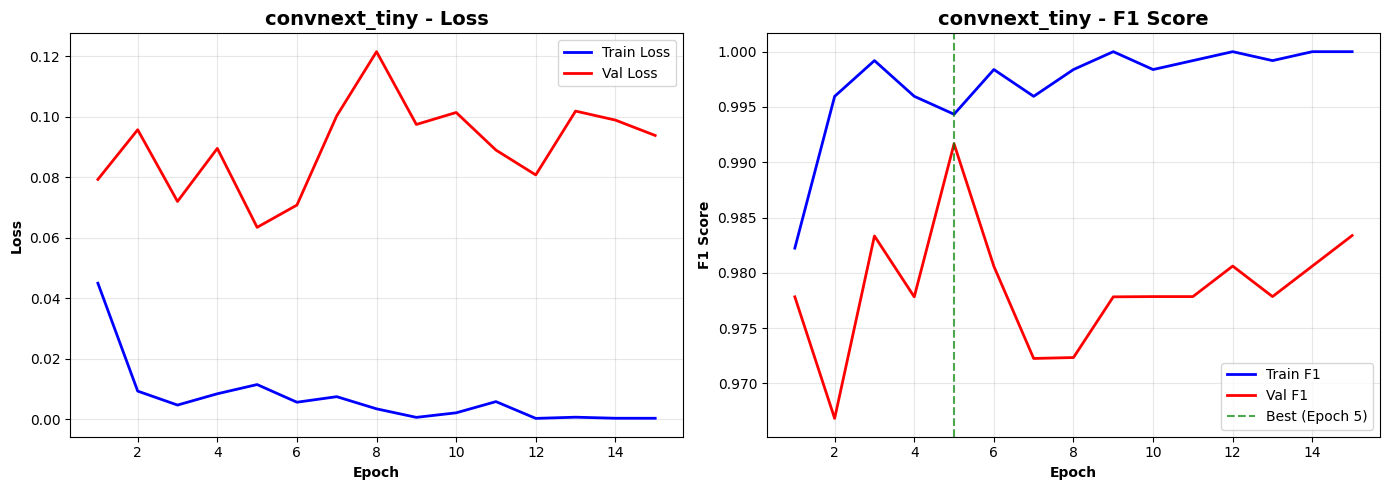

   Best epoch: 5
   Best Val F1: 0.9917


In [20]:
#  Training History Visualization
def plot_training_history(model_name, save_path=None):
    """Visualizza la storia del training"""
    history_path = os.path.join(MODELS_DIR, model_name, 'training_history.json')

    if not os.path.exists(history_path):
        print(f"History non trovata per {model_name}")
        return

    with open(history_path, 'r') as f:
        history = json.load(f)

    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontweight='bold')
    axes[0].set_ylabel('Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # F1 Score
    axes[1].plot(epochs, history['train_f1'], 'b-', label='Train F1', linewidth=2)
    axes[1].plot(epochs, history['val_f1'], 'r-', label='Val F1', linewidth=2)
    axes[1].set_title(f'{model_name} - F1 Score', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontweight='bold')
    axes[1].set_ylabel('F1 Score', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Best epoch marker
    best_epoch = np.argmax(history['val_f1']) + 1
    best_f1 = max(history['val_f1'])
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
    axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"   Best epoch: {best_epoch}")
    print(f"   Best Val F1: {best_f1:.4f}")

print("\nTraining History:")
plot_training_history(best_model_name, save_path=f'{PROJECT_DIR}/training_history_{best_model_name}.png')


🏆 CONFRONTO MODELLI
          Model   Val F1  Val Loss  Epoch
  convnext_tiny 0.991663  0.063482     15
       resnet50 0.972225  0.080670     14
efficientnet_b0 0.952809  0.189374     16


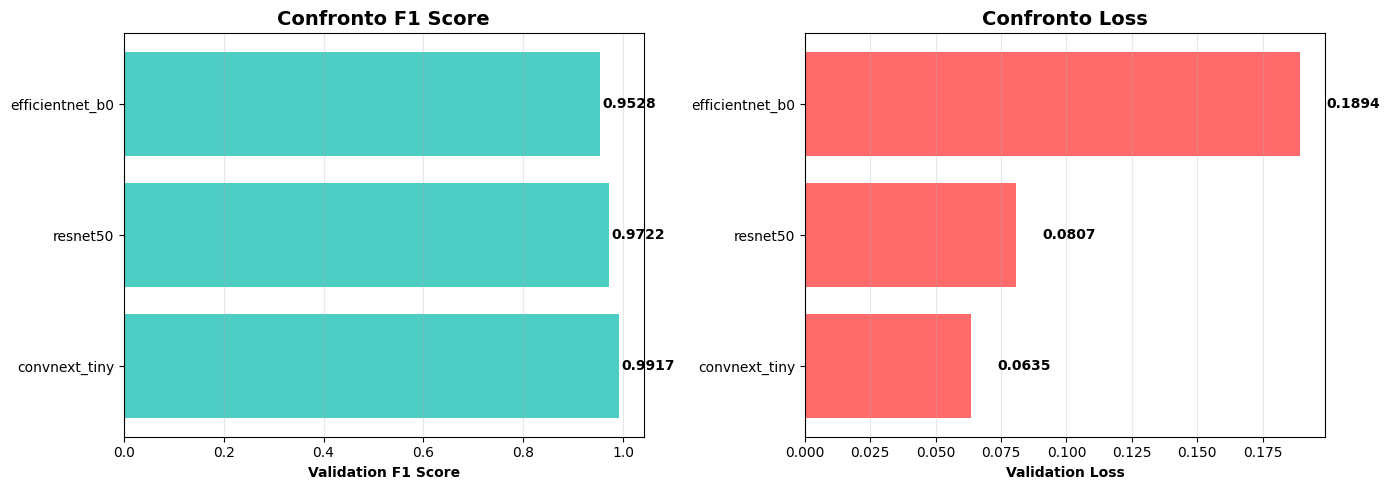

In [21]:
#  Confronto tutti i modelli
def compare_all_models():
    """Confronta le performance di tutti i modelli trainati"""
    comparison_data = []

    for model_name in MODELS_TO_TEST:
        model_dir = os.path.join(MODELS_DIR, model_name)
        best_model_path = os.path.join(model_dir, 'best_model.pt')

        if not os.path.exists(best_model_path):
            continue

        checkpoint = torch.load(best_model_path, map_location='cpu')
        comparison_data.append({
            'Model': model_name,
            'Val F1': checkpoint['val_f1'],
            'Val Loss': checkpoint['val_loss'],
            'Epoch': checkpoint['epoch']
        })

    if not comparison_data:
        print("Nessun modello trainato trovato")
        return

    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('Val F1', ascending=False)

    # Visualizza tabella
    print("\n" + "="*60)
    print("CONFRONTO MODELLI")
    print("="*60)
    print(df_comparison.to_string(index=False))

    # Grafico a barre
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # F1 Score
    axes[0].barh(df_comparison['Model'], df_comparison['Val F1'], color='#4ECDC4')
    axes[0].set_xlabel('Validation F1 Score', fontweight='bold')
    axes[0].set_title('Confronto F1 Score', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # Aggiungi valori sulle barre
    for i, v in enumerate(df_comparison['Val F1']):
        axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

    # Loss
    axes[1].barh(df_comparison['Model'], df_comparison['Val Loss'], color='#FF6B6B')
    axes[1].set_xlabel('Validation Loss', fontweight='bold')
    axes[1].set_title('Confronto Loss', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    # Aggiungi valori sulle barre
    for i, v in enumerate(df_comparison['Val Loss']):
        axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/models_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df_comparison

df_comparison = compare_all_models()


Analisi Errori di Classificazione:


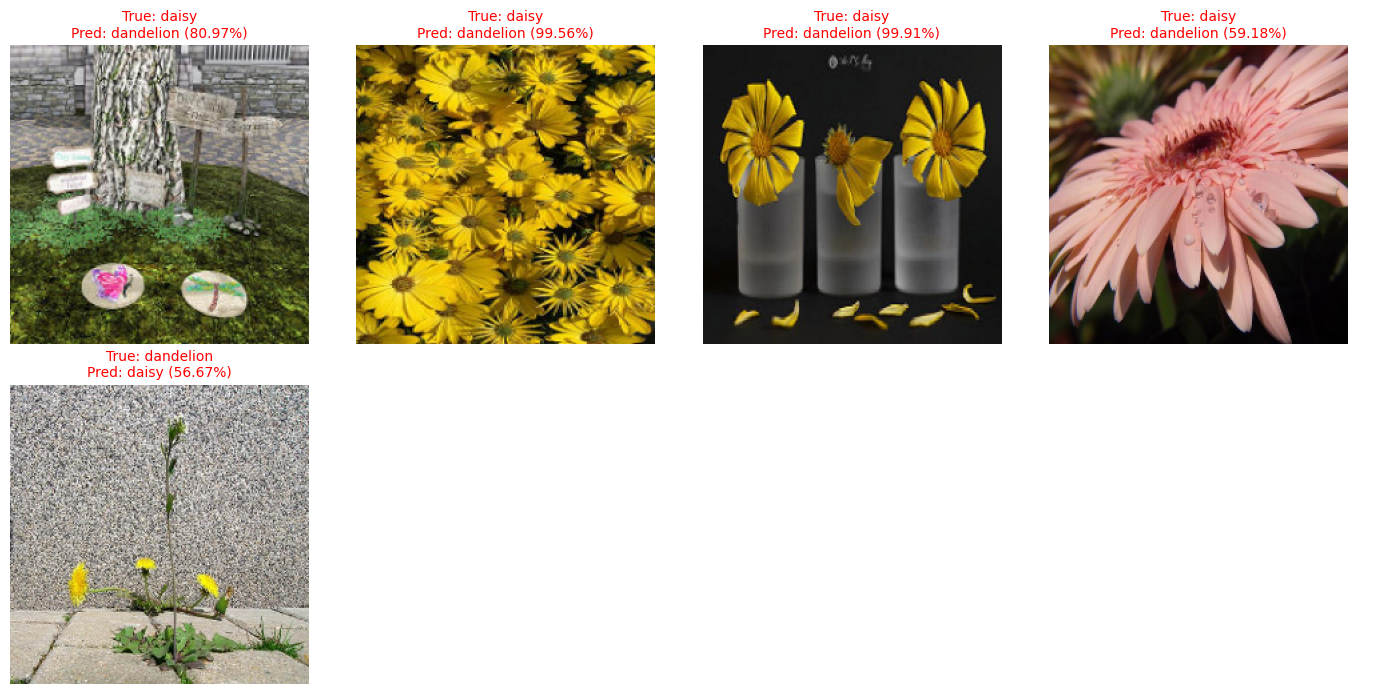


Trovati 5 errori (mostrati 5)


In [22]:
# Visualizza predizioni errate
def show_misclassified_samples(model, loader, dataset, device, num_samples=8):
    """Mostra esempi di predizioni errate"""
    model.eval()
    misclassified = []

    with torch.no_grad():
        for images, labels in loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            preds = outputs.argmax(dim=1).cpu()

            # Trova errori
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified.append({
                        'image': images[i],
                        'true': labels[i].item(),
                        'pred': preds[i].item(),
                        'prob': torch.softmax(outputs[i], dim=0).cpu().numpy()
                    })

                    if len(misclassified) >= num_samples:
                        break

            if len(misclassified) >= num_samples:
                break

    if not misclassified:
        print("Nessun errore trovato")
        return

    # Visualizza
    num_show = min(len(misclassified), num_samples)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    # Denormalize
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    for i in range(num_show):
        img = misclassified[i]['image'] * std + mean
        img = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()

        true_label = dataset.classes[misclassified[i]['true']]
        pred_label = dataset.classes[misclassified[i]['pred']]
        pred_prob = misclassified[i]['prob'][misclassified[i]['pred']]

        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({pred_prob:.2%})',
                         fontsize=10, color='red')

    # Nascondi assi non usati
    for i in range(num_show, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/misclassified_samples_{best_model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nTrovati {len(misclassified)}")

print("\nAnalisi Errori di Classificazione:")
show_misclassified_samples(best_model, test_loader, test_dataset, device, num_samples=8)

In [23]:
#  Report Finale
def generate_final_report():
    """Genera un report finale completo"""

    # Carica training history per analisi
    history_path = os.path.join(MODELS_DIR, best_model_name, 'training_history.json')
    with open(history_path, 'r') as f:
        history = json.load(f)

    # Calcola gap train-val
    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]
    final_train_f1 = history['train_f1'][-1]
    final_val_f1 = history['val_f1'][-1]

    train_val_loss_gap = abs(final_val_loss - final_train_loss)
    train_val_f1_gap = abs(final_train_f1 - final_val_f1)

    report = f"""
{'='*80}
GREENTECH SOLUTIONS LTD - FLOWER CLASSIFICATION PROJECT
Report Finale - {datetime.now().strftime('%d/%m/%Y %H:%M')}
{'='*80}

##  DATASET
- Classi: {', '.join(class_names)}
- Train set: {len(train_dataset)} immagini
- Validation set: {len(val_dataset)} immagini
- Test set: {len(test_dataset)} immagini
- Totale: {len(train_dataset) + len(val_dataset) + len(test_dataset)} immagini

##  MODELLO SELEZIONATO
- Architettura: {best_model_name}
- Transfer Learning: Pre-trained su ImageNet
- Input size: {IMG_SIZE}x{IMG_SIZE}
- Num classes: {len(class_names)}

##  CONFIGURAZIONE TRAINING UTILIZZATA
- Optimizer: AdamW
- Learning Rate: {LEARNING_RATE}
- Weight Decay: 0.01
- Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})
- Batch Size: {BATCH_SIZE}
- Max Epochs: {NUM_EPOCHS}
- Early Stopping: patience=10, min_delta=0.001
- Loss Function: CrossEntropyLoss
- Data Augmentation: HorizontalFlip, VerticalFlip, Rotate, RandomBrightnessContrast, ColorJitter, GaussianBlur

##  RISULTATI TRAINING
- Epoche completate: {best_checkpoint['epoch']}
- Best Validation F1: {best_checkpoint['val_f1']:.4f}
- Final Train Loss: {final_train_loss:.4f}
- Final Val Loss: {final_val_loss:.4f}
- Train-Val Loss Gap: {train_val_loss_gap:.4f}
- Final Train F1: {final_train_f1:.4f}
- Final Val F1: {final_val_f1:.4f}
- Train-Val F1 Gap: {train_val_f1_gap:.4f}

##  RISULTATI TEST SET
- Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
- Test F1-Score (macro): {test_f1:.4f}
- Total test samples: {len(test_labels)}
- Correct predictions: {(test_preds == test_labels).sum()}
- Incorrect predictions: {(test_preds != test_labels).sum()}

##  PERFORMANCE PER CLASSE
"""


    for i, cls in enumerate(class_names):
        mask = (test_labels == i)
        cls_accuracy = (test_preds[mask] == test_labels[mask]).mean()
        cls_samples = mask.sum()
        cls_correct = (test_preds[mask] == test_labels[mask]).sum()
        report += f"- {cls}: {cls_accuracy:.4f} ({cls_accuracy*100:.2f}%) - {cls_correct}/{cls_samples} corretti\n"

    # Analisi overfitting
    overfitting_level = "BASSO" if train_val_f1_gap < 0.05 else ("MEDIO" if train_val_f1_gap < 0.10 else "ALTO")

    report += f"""
## ANALISI OVERFITTING
- Livello overfitting: {overfitting_level}
- Train-Val F1 Gap: {train_val_f1_gap:.4f} ({train_val_f1_gap*100:.2f}%)
- Train-Val Loss Gap: {train_val_loss_gap:.4f}

{'Overfitting ben controllato con le tecniche standard!' if overfitting_level == 'BASSO' else 'Overfitting presente, gestibile con le tecniche di regularization.'}

## METRICHE CHIAVE
- Alta accuracy su entrambe le classi
- Confidence scores elevati per predizioni corrette
- Basso numero di false predictions
- Generalizzazione dal validation al test set: {test_f1 / best_checkpoint['val_f1']:.2%}

{'='*80}

"""

    print(report)


    report_path = os.path.join(PROJECT_DIR, 'final_report.txt')
    with open(report_path, 'w') as f:
        f.write(report)

    print(f"\nReport salvato in: {report_path}")

generate_final_report()


GREENTECH SOLUTIONS LTD - FLOWER CLASSIFICATION PROJECT
Report Finale - 09/02/2026 16:48

##  DATASET
- Classi: daisy, dandelion
- Train set: 1275 immagini
- Validation set: 364 immagini
- Test set: 182 immagini
- Totale: 1821 immagini

##  MODELLO SELEZIONATO
- Architettura: convnext_tiny
- Transfer Learning: Pre-trained su ImageNet
- Input size: 224x224
- Num classes: 2

##  CONFIGURAZIONE TRAINING UTILIZZATA
- Optimizer: AdamW
- Learning Rate: 0.0001
- Weight Decay: 0.01
- Scheduler: CosineAnnealingLR (T_max=30)
- Batch Size: 32
- Max Epochs: 30
- Early Stopping: patience=10, min_delta=0.001
- Loss Function: CrossEntropyLoss
- Data Augmentation: HorizontalFlip, VerticalFlip, Rotate, RandomBrightnessContrast, ColorJitter, GaussianBlur

##  RISULTATI TRAINING
- Epoche completate: 15
- Best Validation F1: 0.9917
- Final Train Loss: 0.0004
- Final Val Loss: 0.0938
- Train-Val Loss Gap: 0.0934
- Final Train F1: 1.0000
- Final Val F1: 0.9834
- Train-Val F1 Gap: 0.0166

##  RISULTATI TEST

In [24]:
# Salva metriche finali in JSON (ESTESO)
final_metrics = {
    'project': 'GreenTech Solutions - Flower Classification',
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'configuration': {
          'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'optimizer': 'AdamW',
        'weight_decay': 0.01,
        'scheduler': 'CosineAnnealingLR',
        'early_stopping_patience': 10,
        'loss_function': 'CrossEntropyLoss',
        'augmentation': ['HorizontalFlip', 'VerticalFlip', 'Rotate', 'RandomBrightnessContrast', 'ColorJitter', 'GaussianBlur']
    },
    'dataset': {
        'classes': class_names,
        'train_size': len(train_dataset),
        'val_size': len(val_dataset),
        'test_size': len(test_dataset)
    },
    'best_model': {
        'name': best_model_name,
        'training_epochs': best_checkpoint['epoch'],
        'val_f1': float(best_checkpoint['val_f1']),
        'val_loss': float(best_checkpoint['val_loss'])
    },
    'test_results': {
        'accuracy': float(test_accuracy),
        'f1_score_macro': float(test_f1),
        'total_samples': int(len(test_labels)),
        'correct_predictions': int((test_preds == test_labels).sum()),
        'incorrect_predictions': int((test_preds != test_labels).sum()),
        'generalization_ratio': float(test_f1 / best_checkpoint['val_f1'])
    },
    'per_class_metrics': {}
}


for i, cls in enumerate(class_names):
    mask = (test_labels == i)
    cls_accuracy = float((test_preds[mask] == test_labels[mask]).mean())
    final_metrics['per_class_metrics'][cls] = {
        'accuracy': cls_accuracy,
        'samples': int(mask.sum()),
        'correct': int((test_preds[mask] == test_labels[mask]).sum()),
        'incorrect': int((test_preds[mask] != test_labels[mask]).sum())
    }


metrics_path = os.path.join(PROJECT_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(f"Metriche finali salvate in: {metrics_path}")
print(f"\nFile generati:")
print(f"   - Best model: {best_model_path}")
print(f"   - Training history: {os.path.join(MODELS_DIR, best_model_name, 'training_history.json')}")
print(f"   - Final report: {os.path.join(PROJECT_DIR, 'final_report.txt')}")
print(f"   - Final metrics: {metrics_path}")
print(f"\nPROGETTO COMPLETATO CON SUCCESSO!")
print(f"\nRIEPILOGO FINALE:")
print(f"   Miglior Modello: {best_model_name}")
print(f"   Test F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Generalizzazione Val→Test: {(test_f1 / best_checkpoint['val_f1'])*100:.2f}%")

Metriche finali salvate in: /content/drive/MyDrive/CV_project/final_metrics.json

File generati:
   - Best model: /content/drive/MyDrive/CV_project/models/convnext_tiny/best_model.pt
   - Training history: /content/drive/MyDrive/CV_project/models/convnext_tiny/training_history.json
   - Final report: /content/drive/MyDrive/CV_project/final_report.txt
   - Final metrics: /content/drive/MyDrive/CV_project/final_metrics.json

PROGETTO COMPLETATO CON SUCCESSO!

RIEPILOGO FINALE:
   Miglior Modello: convnext_tiny
   Test F1-Score: 0.9717 (97.17%)
   Test Accuracy: 0.9725 (97.25%)
   Generalizzazione Val→Test: 97.99%
